In [55]:
%load_ext autoreload
%autoreload 2
import torch
from Systems import Lorenz
import numpy as np
from NN import NN
import matplotlib.pyplot as plt
from Observer import Observer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
#------------- Lorenz Attractor ------------- 
rho = 28
sigma = 10
beta = 8/3

a = 0
b = 50
N = 1000
num_ic = 50

M = np.array([[-2.12116939,  2.73877907, -0.75338041,  3.13947511,  1.00581224,
    -5.34548426, -5.34544528],
[-5.91811463, -1.99160105, -0.26953991,  0.45654273, -0.56750459,
    -3.79023002, -3.00480715],
[-1.27814843, -2.08375366, -2.60781906, -4.11186517,  0.33087248,
    0.08191241, -2.81998688],
[ 0.69080313,  2.00687664,  3.02478991, -3.53231915, -0.89704804,
    -5.19153027,  3.16796666],
[-1.16566857, -0.53979687, -0.30300461, -3.79753229, -2.7939018 ,
    -0.30176078, -2.61480264],
[ 2.97899741,  3.97265572, -2.04951338, -1.08716448, -0.98741222,
    -4.7047881 , -1.38218644],
[ 0.95887295,  0.43056828, -1.39564903, -3.18608794,  3.74388666,
    -3.88509855, -3.07468653]])

K = np.ones([7,1])

limits = np.array([[-1,1], [-1,1], [-1,1]])    # Sample space
lorenz = Lorenz(rho, sigma, beta, noise_measurement_std=5, noise_process_std=5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_data = torch.load('models/lorenz_T_inverse_lr0.001_batch32_epoch15',map_location=torch.device('cpu'))
num_hidden = model_data['config']['num_hidden']
hidden_size = model_data['config']['hidden_size']
x_size = model_data['config']['x_size']
z_size = model_data['config']['z_size']
activation = model_data['config']['activation']
normalizer = model_data['config']['normalizer']
T_inv_net = NN(num_hidden, hidden_size, z_size, x_size, activation, normalizer=normalizer).to(device)
T_inv_net.load_state_dict(model_data['model'])
T_inv_net.eval()

observer2 = Observer(lorenz, M, K, T_inv_net, a, b, N, init_z_zero=True)

initial_conds = np.arange(0.1, 5.1, 0.1)
MAE_x_list_new = []
MAE_y_list_new = []

# for ic in initial_conds:
#     ic = np.array([[ic, ic, ic]])
#     x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
#     MAE_x = np.mean(error[0][:,0])
#     MAE_y = np.mean(error[0][:,1])
#     MAE_x_list_new.append(MAE_x)
#     MAE_y_list_new.append(MAE_y)

# fig = plt.figure(figsize = (8,8), facecolor='w')
# plt.plot(initial_conds, MAE_x_list_new, label = 'MAE x')
# plt.plot(initial_conds, MAE_y_list_new, label = 'MAE y')
# plt.legend()
# plt.title('New Method')
# plt.xlabel('Initial (x0,y0)')
# plt.ylabel('Mean Absolute Error')
# plt.show()

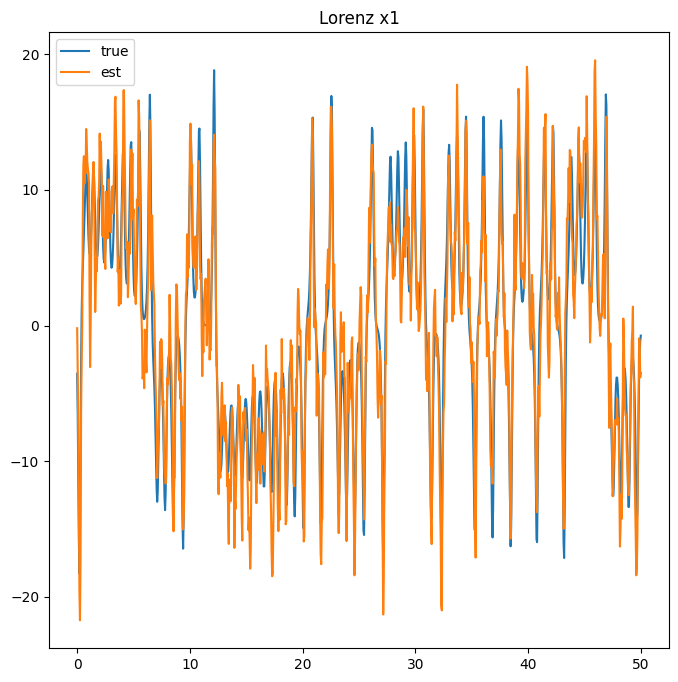

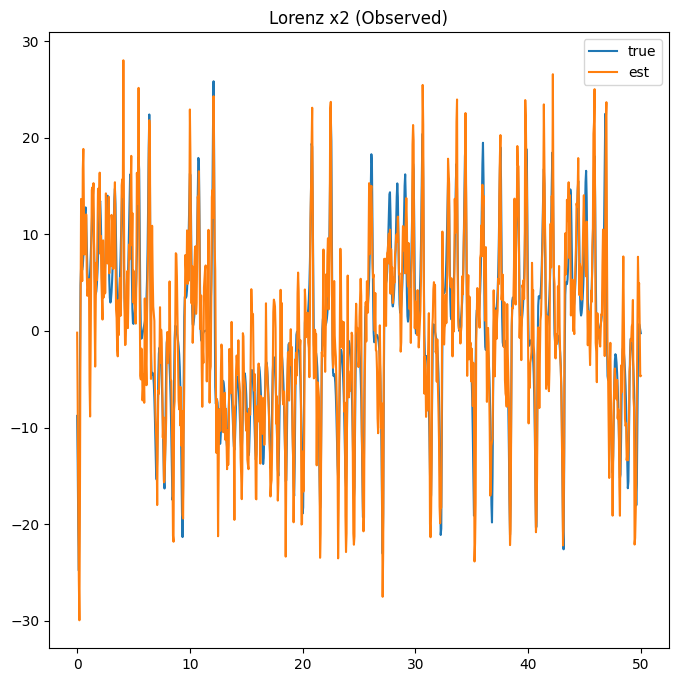

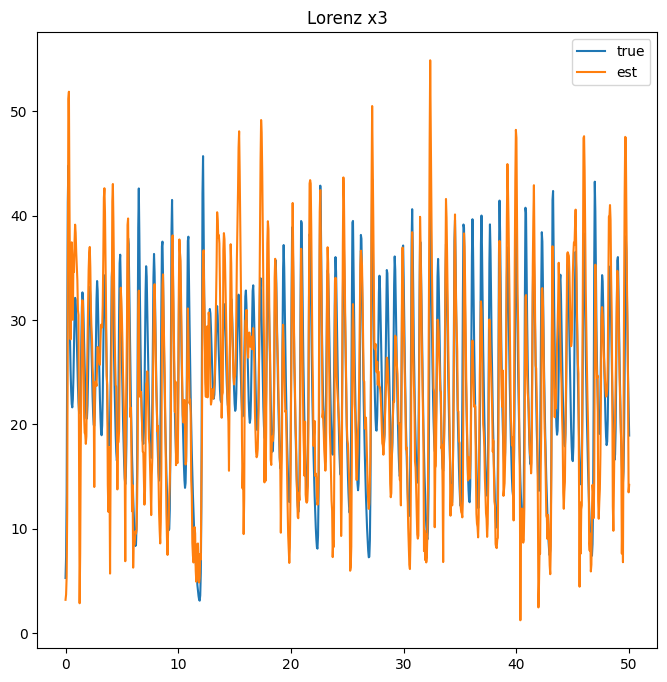

In [63]:
ic = np.array([[0.5, 0.5, 0.5]])
ic = np.random.uniform(-10,10,[1,3])

x, x_hat, t, error = observer2.simulate(ic, add_noise = True)

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,0], label = 'true')
plt.plot(t, x_hat[:,0], label = 'est')
plt.title('Lorenz x1')
plt.legend()
plt.show()

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,1], label = 'true')
plt.plot(t, x_hat[:,1], label = 'est')
plt.title('Lorenz x2 (Observed)')
plt.legend()
plt.show()

fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,2], label = 'true')
plt.plot(t, x_hat[:,2], label = 'est')
plt.title('Lorenz x3')
plt.legend()
plt.show()

In [6]:
def eval_errors(xs, xs_predict):
    errs = np.sqrt(((xs - xs_predict) ** 2).mean(-1).mean(0))
    tot = errs.mean()
    return tot

num_ic = 1000
init_conds = np.random.uniform(-1,1,[num_ic,1,3])

x_true = np.zeros([num_ic, N+1, lorenz.x_size])
x_pred = np.zeros([num_ic, N+1, lorenz.x_size])

for idx, ic in enumerate(init_conds):
    x, x_hat, t, error = observer2.simulate(ic, add_noise = False)
    x_true[idx, :,:] = x
    x_pred[idx, :,:] = x_hat

x_true = x_true[:,50:,:]
x_pred = x_pred[:,50:,:]


print(eval_errors(x_true, x_pred))

0.22757214465037606
